# TP3 — EDA de Contenido: Longitud, Hashtags, Menciones y Wordclouds

**Alumno:** Gonzalo Zarazaga

---

`00_lectura_y_discovery.ipynb` cubrió estructura, esquema, nulos, duplicados y la comparación entre archivos — pero no patrones del **contenido textual** en sí. Este notebook lo completa: longitud de tweets, hashtags y menciones más frecuentes (en general y por polaridad), y wordclouds por clase.

**Insumo:** `data/raw/training.1600000.processed.noemoticon.csv.gz` (texto crudo, necesario para hashtags/menciones intactos — `01_preprocesamiento.ipynb` ya les saca el `#`/`@`), `data/processed/train_processed.csv.gz` (para los wordclouds, sobre texto ya limpio)
**Salida:** hallazgos de contenido, sin impacto en decisiones de pipeline ya tomadas — es EDA complementario, no insumo de otro notebook.

## 1. Carga de datos

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

COLS = ["polarity", "id", "date", "query", "user", "text"]
df = pd.read_csv("../data/raw/training.1600000.processed.noemoticon.csv.gz", encoding="latin-1", names=COLS)
print(f"{len(df):,} tweets cargados")

1,600,000 tweets cargados


## 2. Longitud de tweets

Se mide en caracteres y en palabras (split simple por espacios, sobre texto crudo).

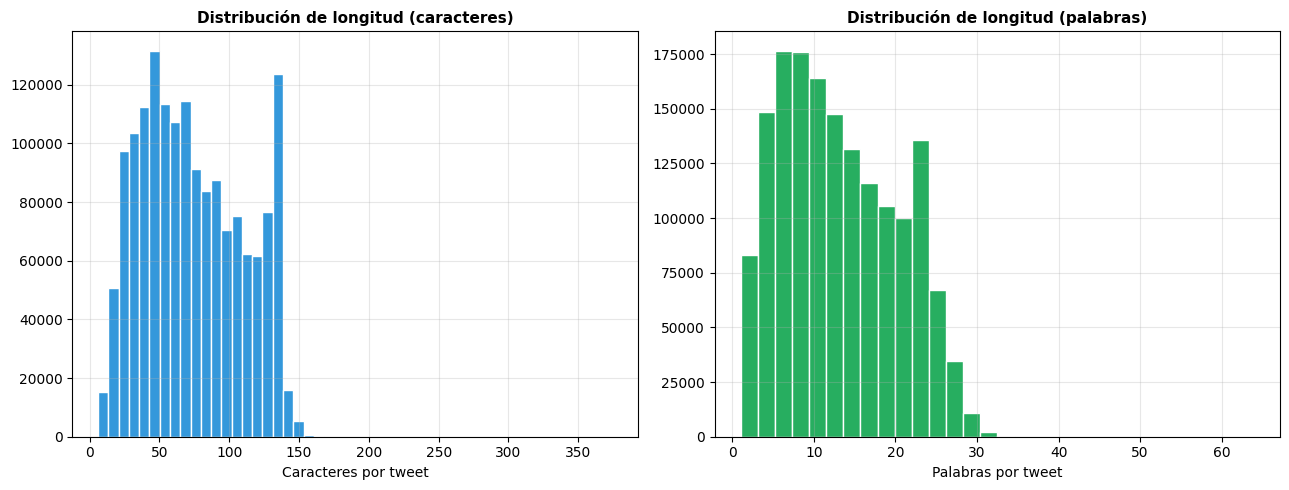

            n_chars       n_words
count  1.600000e+06  1.600000e+06
mean   7.409011e+01  1.317615e+01
std    3.644114e+01  6.957978e+00
min    6.000000e+00  1.000000e+00
25%    4.400000e+01  7.000000e+00
50%    6.900000e+01  1.200000e+01
75%    1.040000e+02  1.900000e+01
max    3.740000e+02  6.400000e+01


In [2]:
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df["n_chars"], bins=50, color="#3498db", edgecolor="white")
axes[0].set_title("Distribución de longitud (caracteres)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Caracteres por tweet")
axes[0].grid(alpha=0.3)

axes[1].hist(df["n_words"], bins=30, color="#27ae60", edgecolor="white")
axes[1].set_title("Distribución de longitud (palabras)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Palabras por tweet")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(df[["n_chars", "n_words"]].describe())

In [3]:
resumen_por_clase = df.groupby("polarity")[["n_chars", "n_words"]].agg(["mean", "median"])
resumen_por_clase.index = ["Negativo (0)", "Positivo (4)"]
resumen_por_clase

n_chars           n_words       
                   mean median       mean median
Negativo (0)  74.301790   70.0  13.581984   13.0
Positivo (4)  73.878433   69.0  12.770318   12.0

**Hallazgo:** los tweets negativos son, en promedio, levemente más largos que los positivos (ver tabla). Consistente con la intuición de que quejarse/explicar un problema típicamente toma más palabras que una expresión positiva corta ("love it!", "so happy"). La diferencia es chica pero consistente en media y mediana.

## 3. Hashtags: los más frecuentes, en general y por clase

Solo \~2,2% de los tweets tienen hashtag (ver `01_preprocesamiento.ipynb`), así que este análisis es sobre una porción chica del corpus — pero interesante para ver qué temas/rituales de Twitter aparecen.

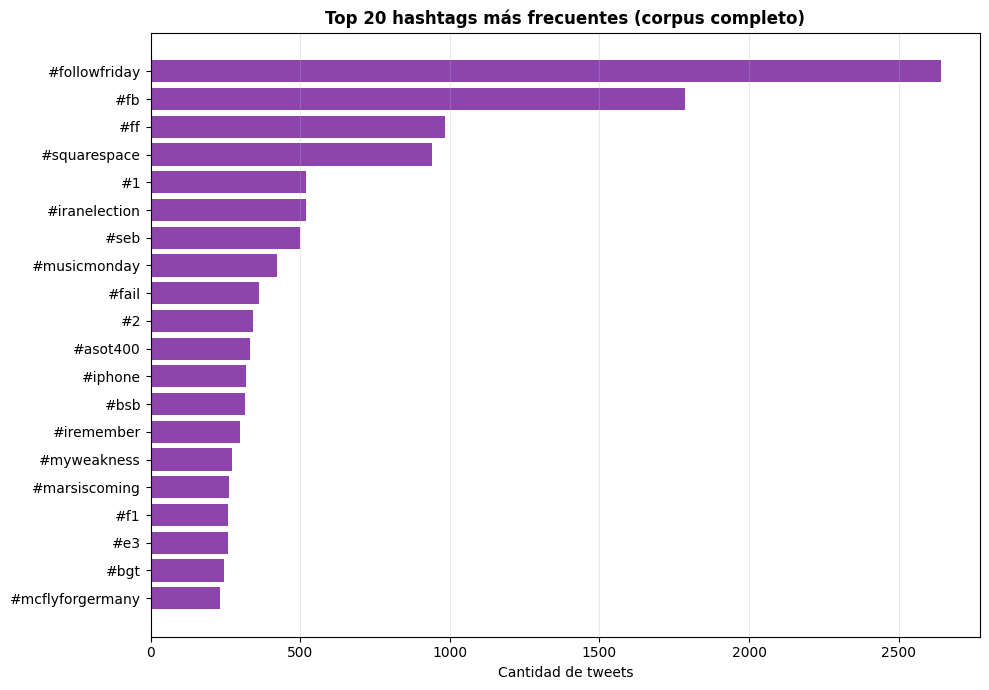

In [4]:
HASHTAG_RE = re.compile(r"#\w+")
df["hashtags"] = df["text"].str.lower().apply(HASHTAG_RE.findall)

todos_hashtags = Counter(h for lista in df["hashtags"] for h in lista)
top20 = todos_hashtags.most_common(20)

fig, ax = plt.subplots(figsize=(10, 7))
etiquetas, conteos = zip(*top20)
ax.barh(etiquetas[::-1], conteos[::-1], color="#8e44ad")
ax.set_title("Top 20 hashtags más frecuentes (corpus completo)", fontsize=12, fontweight="bold")
ax.set_xlabel("Cantidad de tweets")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

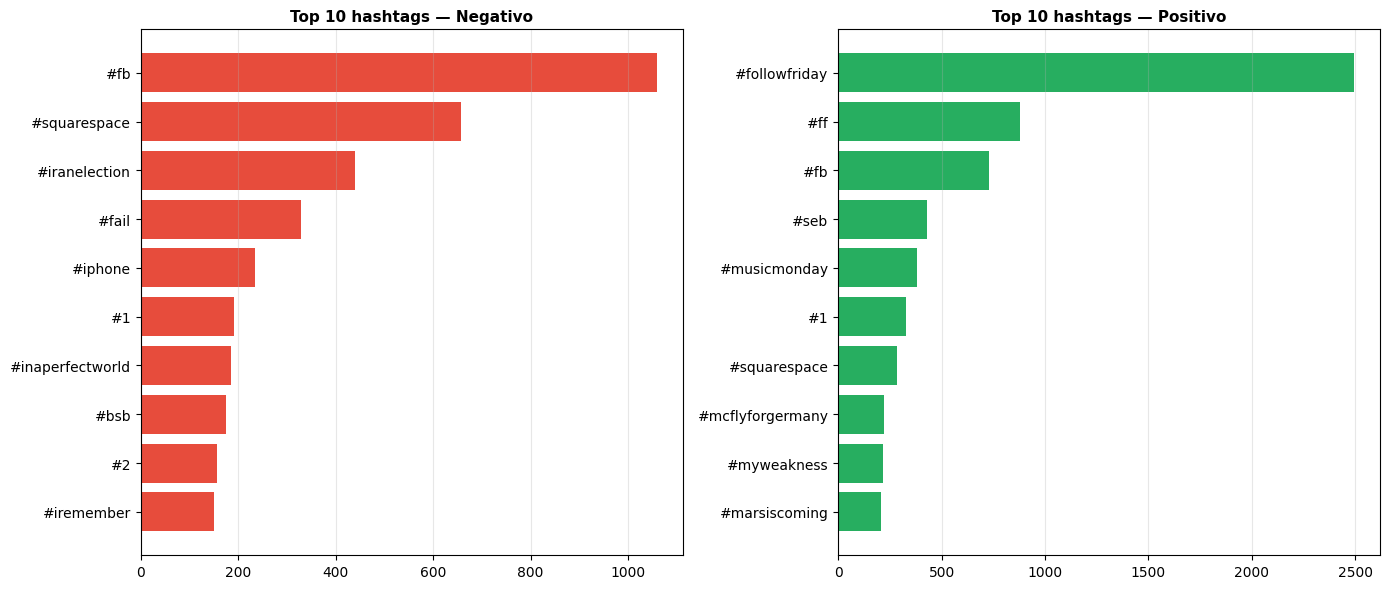

In [5]:
hashtags_neg = Counter(h for lista in df[df["polarity"] == 0]["hashtags"] for h in lista)
hashtags_pos = Counter(h for lista in df[df["polarity"] == 4]["hashtags"] for h in lista)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, contador, titulo, color in zip(
    axes, [hashtags_neg, hashtags_pos], ["Top 10 hashtags — Negativo", "Top 10 hashtags — Positivo"], ["#e74c3c", "#27ae60"]
):
    top10 = contador.most_common(10)
    etiquetas, conteos = zip(*top10)
    ax.barh(etiquetas[::-1], conteos[::-1], color=color)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Hallazgo:** `#followfriday`/`#ff` (convención de Twitter para recomendar cuentas, un ritual social positivo) domina claramente el lado positivo. `#fail` y `#iranelection` aparecen entre los más frecuentes del lado negativo — este último conecta directamente con el hallazgo de `05_topicos_temporales.ipynb`: el hashtag `#iranelection` tiene 518 menciones en todo el corpus, y su presencia está sesgada hacia tweets negativos, coherente con el \~86% de sentimiento negativo medido ahí sobre el tópico completo.

## 4. Menciones más frecuentes

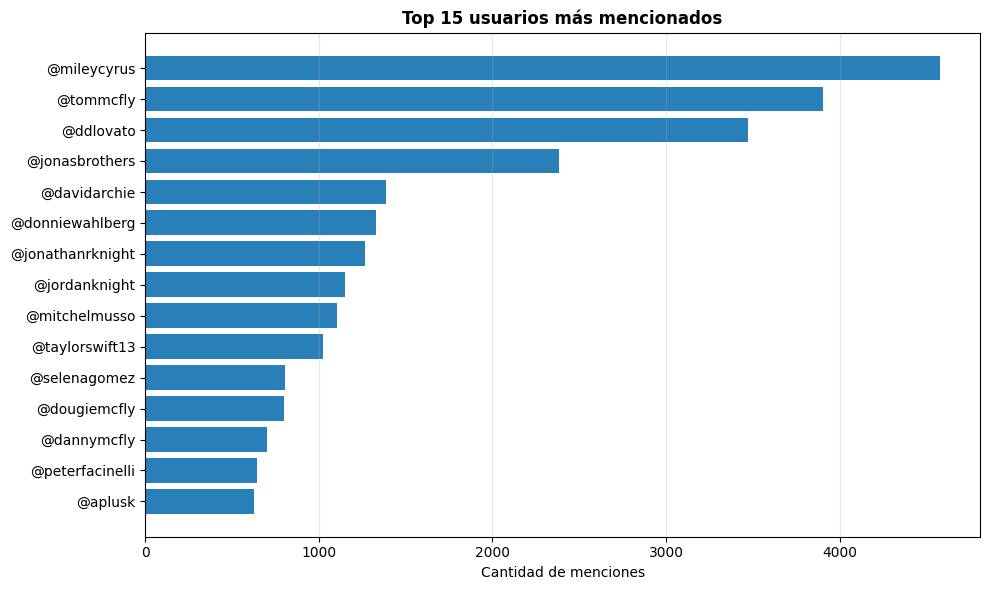

In [6]:
MENTION_RE = re.compile(r"@\w+")
df["mentions"] = df["text"].str.lower().apply(MENTION_RE.findall)

todas_mentions = Counter(m for lista in df["mentions"] for m in lista)
top15 = todas_mentions.most_common(15)

fig, ax = plt.subplots(figsize=(10, 6))
etiquetas, conteos = zip(*top15)
ax.barh(etiquetas[::-1], conteos[::-1], color="#2980b9")
ax.set_title("Top 15 usuarios más mencionados", fontsize=12, fontweight="bold")
ax.set_xlabel("Cantidad de menciones")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Hallazgo:** las cuentas más mencionadas son celebridades/músicos pop de 2009 (Miley Cyrus, Tom Fletcher de McFly, Demi Lovato, Jonas Brothers, David Archuleta, Taylor Swift) — consistente con la demografía temprana de Twitter, sesgada a fandom adolescente/pop. Ratifica que este es un corpus de charla cotidiana y cultura pop, no de temas noticiosos (ver también la aclaración de `06_conclusiones.ipynb` sobre que Irán no es "el tópico principal" del dataset).

## 5. Wordclouds por polaridad

Comparación antes/después del pipeline de limpieza (`01_preprocesamiento.ipynb`): primero el texto crudo (sin procesar) y después el texto ya limpio, para evidenciar visualmente el ruido que la limpieza elimina (URLs, menciones, emoticones, entidades HTML sin decodificar). Se muestrean 200.000 tweets por clase en cada caso para que el cómputo sea rápido sin perder representatividad.

### 5.1 Antes de la limpieza (texto crudo)

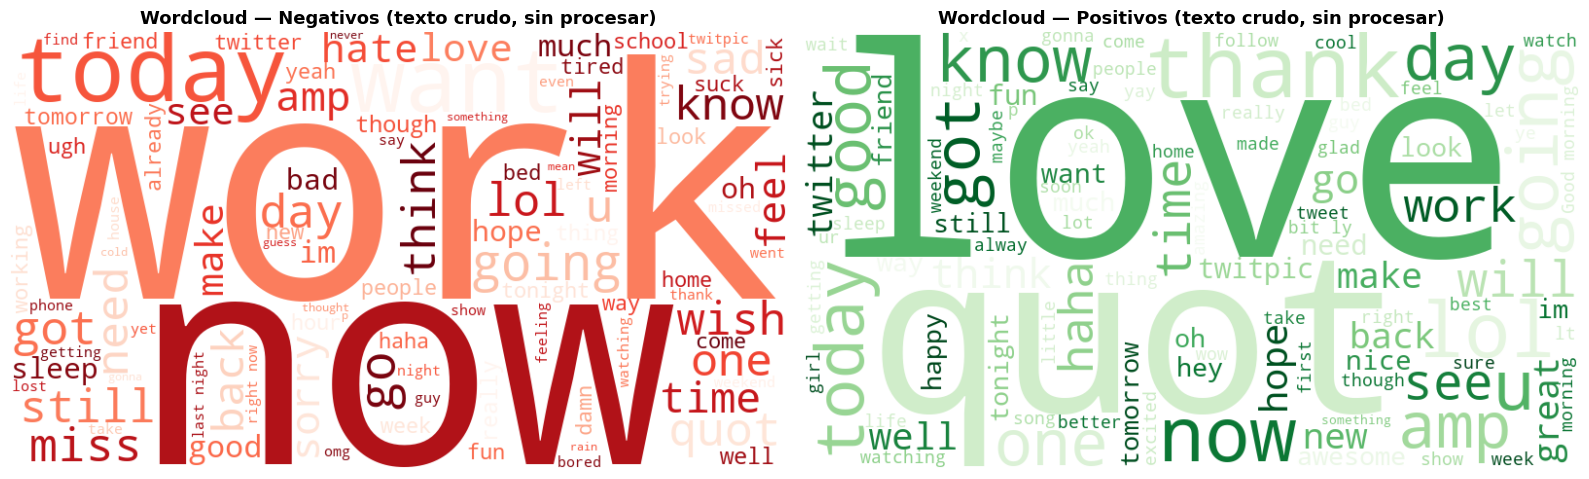

In [7]:
RANDOM_STATE = 42
MUESTRA = 200000

texto_neg_crudo = " ".join(df[df["polarity"] == 0]["text"].sample(MUESTRA, random_state=RANDOM_STATE))
texto_pos_crudo = " ".join(df[df["polarity"] == 4]["text"].sample(MUESTRA, random_state=RANDOM_STATE))

wc_neg_crudo = WordCloud(width=800, height=450, background_color="white", max_words=100, colormap="Reds").generate(texto_neg_crudo)
wc_pos_crudo = WordCloud(width=800, height=450, background_color="white", max_words=100, colormap="Greens").generate(texto_pos_crudo)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(wc_neg_crudo, interpolation="bilinear")
axes[0].set_title("Wordcloud — Negativos (texto crudo, sin procesar)", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(wc_pos_crudo, interpolation="bilinear")
axes[1].set_title("Wordcloud — Positivos (texto crudo, sin procesar)", fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

**Hallazgo:** aun con el tokenizador y el stopword-set genérico en inglés que aplica `WordCloud` por defecto, el texto crudo deja pasar ruido concreto que la limpieza específica de tweets (`01_preprocesamiento.ipynb`) elimina: `quot` y `amp` aparecen como palabras visibles en ambas clases — restos de `&quot;`/`&amp;` sin decodificar — y `ly`/`twitpic` (fragmentos de URLs y acortadores) también se cuelan. Es evidencia visual directa de por qué decodificar entidades HTML y eliminar URLs son pasos necesarios del pipeline, no una limpieza cosmética.

### 5.2 Después de la limpieza (texto final)

Sobre el texto ya limpio (`train_processed.csv.gz`, tokens sin URLs/menciones/emoticones/símbolo `#`), muestreando 200.000 tweets por clase para que el cómputo sea rápido sin perder representatividad.

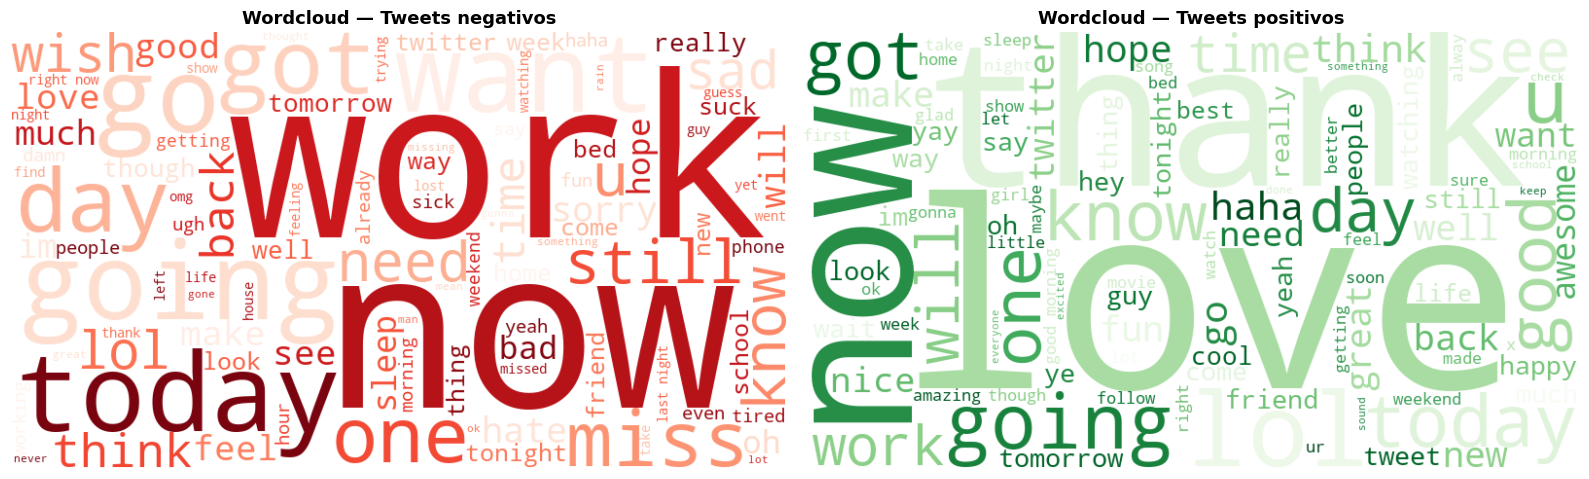

In [8]:
df_proc = pd.read_csv("../data/processed/train_processed.csv.gz")

RANDOM_STATE = 42
MUESTRA = 200000

texto_neg = " ".join(df_proc[df_proc["polarity"] == 0]["tokens"].astype(str).sample(MUESTRA, random_state=RANDOM_STATE))
texto_pos = " ".join(df_proc[df_proc["polarity"] == 4]["tokens"].astype(str).sample(MUESTRA, random_state=RANDOM_STATE))

wc_neg = WordCloud(width=800, height=450, background_color="white", max_words=100, colormap="Reds").generate(texto_neg)
wc_pos = WordCloud(width=800, height=450, background_color="white", max_words=100, colormap="Greens").generate(texto_pos)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(wc_neg, interpolation="bilinear")
axes[0].set_title("Wordcloud — Tweets negativos", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(wc_pos, interpolation="bilinear")
axes[1].set_title("Wordcloud — Tweets positivos", fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. Marcadores de intensidad emocional (puntuación y ortografía)

Señal puramente léxica/ortográfica calculada directo sobre el texto crudo — signos de exclamación e interrogación, palabras en MAYÚSCULAS, y elongación de letras ("soooo", "yesss"). No depende de ningún modelo entrenado ni de los tópicos de `05_topicos_temporales.ipynb`: es el tipo de EDA que podría haberse hecho al principio del TP, antes de correr nada.

/var/folders/cs/ml7k4dkn58b6qnbwdj8rxhj40000gn/T/ipykernel_11482/3826991057.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_elong"] = df["text"].str.contains(r"([a-zA-Z])\1{2,}", regex=True)


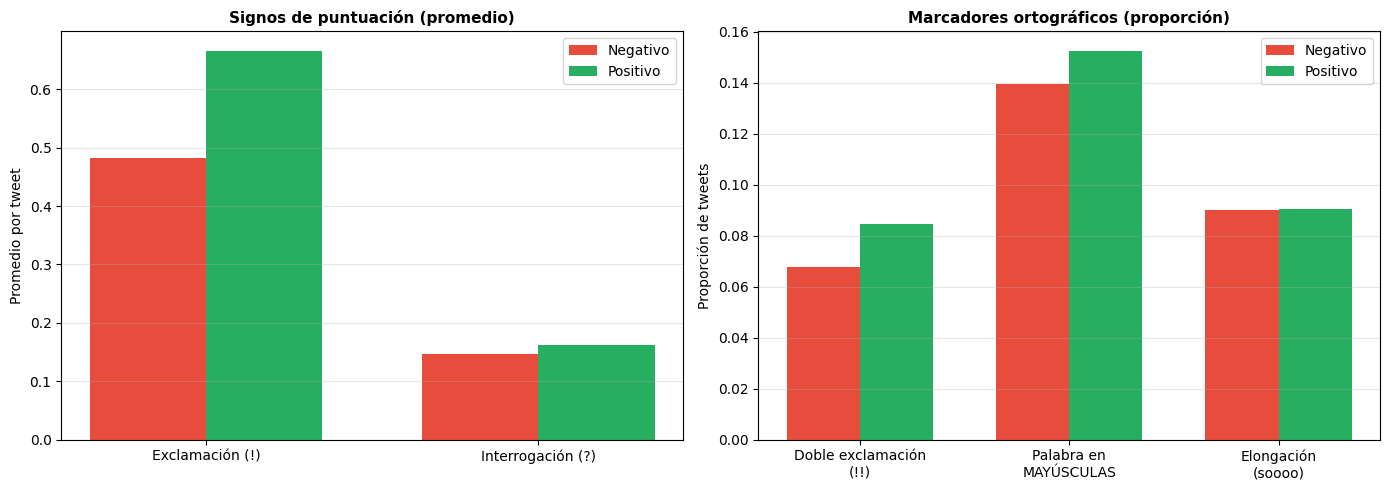

,n_excl,n_quest,has_multi_excl,has_caps_word,has_elong
Negativo (0),0.481538,0.146766,0.067534,0.139609,0.089995
Positivo (4),0.665900,0.162686,0.084589,0.152551,0.090334


In [9]:
df["n_excl"] = df["text"].str.count("!")
df["n_quest"] = df["text"].str.count(r"\?")
df["has_multi_excl"] = df["text"].str.contains("!!", regex=False)
df["has_caps_word"] = df["text"].str.contains(r"\b[A-Z]{2,}\b", regex=True)
df["has_elong"] = df["text"].str.contains(r"([a-zA-Z])\1{2,}", regex=True)

cols_intensidad = ["n_excl", "n_quest", "has_multi_excl", "has_caps_word", "has_elong"]
resumen_intensidad = df.groupby("polarity")[cols_intensidad].mean()
resumen_intensidad.index = ["Negativo (0)", "Positivo (4)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.35

etiquetas_conteo = ["Exclamación (!)", "Interrogación (?)"]
x1 = np.arange(len(etiquetas_conteo))
axes[0].bar(x1 - width/2, resumen_intensidad.loc["Negativo (0)", ["n_excl", "n_quest"]], width, label="Negativo", color="#e74c3c")
axes[0].bar(x1 + width/2, resumen_intensidad.loc["Positivo (4)", ["n_excl", "n_quest"]], width, label="Positivo", color="#27ae60")
axes[0].set_xticks(x1)
axes[0].set_xticklabels(etiquetas_conteo)
axes[0].set_ylabel("Promedio por tweet")
axes[0].set_title("Signos de puntuación (promedio)", fontsize=11, fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

etiquetas_prop = ["Doble exclamación\n(!!)", "Palabra en\nMAYÚSCULAS", "Elongación\n(soooo)"]
x2 = np.arange(len(etiquetas_prop))
axes[1].bar(x2 - width/2, resumen_intensidad.loc["Negativo (0)", ["has_multi_excl", "has_caps_word", "has_elong"]], width, label="Negativo", color="#e74c3c")
axes[1].bar(x2 + width/2, resumen_intensidad.loc["Positivo (4)", ["has_multi_excl", "has_caps_word", "has_elong"]], width, label="Positivo", color="#27ae60")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(etiquetas_prop)
axes[1].set_ylabel("Proporción de tweets")
axes[1].set_title("Marcadores ortográficos (proporción)", fontsize=11, fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

resumen_intensidad

**Hallazgo:** de los cinco marcadores, solo la exclamación separa claramente las clases: los tweets positivos usan casi 40% más signos de exclamación en promedio (0,666 vs. 0,482) y tienen más tweets con "!!" (8,5% vs. 6,8%). El resto es sorprendentemente parecido entre clases: los signos de interrogación (0,163 vs. 0,147), las palabras en MAYÚSCULAS (15,3% vs. 14,0%) y, más llamativo, la elongación de letras ("sooo", "yesss") casi no distingue nada entre negativos y positivos (9,0% vs. 9,0%, prácticamente idéntico) — contradice la intuición de que alargar letras sea un marcador de entusiasmo positivo; en este corpus se usa tanto para enfatizar frustración ("noooo", "ughhh") como alegría ("yesss"). Es un hallazgo genuinamente independiente: surge de conteos sobre el texto crudo, sin depender de ningún modelo entrenado ni de los tópicos de `05_topicos_temporales.ipynb`.

## 7. Conclusiones

- **Longitud**: los tweets negativos son levemente más largos (en caracteres y palabras) que los positivos — patrón chico pero consistente.
- **Hashtags** (presentes en solo \~2,2% de los tweets): `#followfriday`/`#ff` domina el lado positivo (ritual social de Twitter), `#fail` y `#iranelection` se destacan del lado negativo — el hashtag de Irán conecta directamente con el hallazgo del diferenciador de tópicos.
- **Menciones** (presentes en \~46% de los tweets): dominadas por celebridades pop de 2009 — confirma, desde otro ángulo, que el corpus es mayormente charla cotidiana/fandom y no contenido noticioso, coherente con lo encontrado en `05_topicos_temporales.ipynb` sobre los tópicos dominantes.
- **Marcadores de intensidad** (puntuación/ortografía, independiente de cualquier modelo): solo la exclamación separa las clases con claridad (positivos usan \~40% más "!" en promedio); interrogación, MAYÚSCULAS y elongación de letras ("soooo") resultaron sorprendentemente parecidas entre negativos y positivos, contra la intuición inicial.
- **Wordclouds**: dan una lectura cualitativa rápida del vocabulario dominante por clase, complementaria a los vecinos de Word2Vec de `03_word2vec.ipynb` (que ya cubren la similitud semántica de palabras de sentimiento) y a los tópicos de BERTopic (que cubren agrupamiento temático).
- Este notebook es EDA complementario: no cambia ninguna decisión de pipeline ya tomada, pero completa la exploración de contenido que faltaba en `00_lectura_y_discovery.ipynb`.